# Occupational Map

## Intro

Goal: Use PCA to create an interactive map showing similarities between different occupations to help people explore career opportunities.

dataset source: https://www.onetcenter.org/database.html#all-files

## Libraries

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import cosine_similarity

## Helper Functions

In [132]:
def missing_values_hist_plot(df, bins, axis):
    sns.histplot(df.isna().sum(axis = axis), bins = bins)
    if axis == 0:
        plt.title('Distribution of Number of Occupations with that Many Missing Metrics')
        plt.xlabel('Number of Missing Metrics')
        plt.ylabel('Number of Occupations')
    elif axis == 1:
        plt.title('Distribution of Number of Metrics Missing from that many occupations')
        plt.xlabel('Number of Occupations')
        plt.ylabel('Number of Missing Metrics')
    plt.show()

In [144]:
def drop_missing_values(df, axis, min_missing_values):
    return df.dropna(axis = axis, thresh = df_pivoted.shape[1 if axis == 0 else 0] - min_missing_values)

## EDA

Our dataset is comprised of many tables, each pertaining to a different measure of components that make up each occupation. Lets just start by looking at one of these files:

In [2]:
knowledge = pd.read_excel('db_28_2_excel/Knowledge.xlsx')

In [3]:
knowledge.head()

,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,2.C.1.a,Administration and Management,IM,Importance,4.78,28.0,0.1102,4.5564,5.0000,N,NaN,08/2023,Incumbent
1,11-1011.00,Chief Executives,2.C.1.a,Administration and Management,LV,Level,6.50,28.0,0.2130,6.0666,6.9409,N,N,08/2023,Incumbent
2,11-1011.00,Chief Executives,2.C.1.b,Administrative,IM,Importance,2.42,28.0,0.4651,1.4662,3.3749,N,NaN,08/2023,Incumbent
3,11-1011.00,Chief Executives,2.C.1.b,Administrative,LV,Level,2.69,28.0,0.8678,0.9078,4.4690,N,N,08/2023,Incumbent
4,11-1011.00,Chief Executives,2.C.1.c,Economics and Accounting,IM,Importance,4.04,28.0,0.3480,3.3246,4.7526,N,NaN,08/2023,Incumbent


The key metric here is the 'Data Value' for each 'Element Name'/'Element ID', 'Scale Name'/'Scale ID' combination. These metrics will form our vectors such that each row will be a single 'O*NET-SOC Code' and each colum a separate metric. Lets bring in our other data and merge them together to create our working dataset:

In [16]:
# first specify which datasets we want to import (all datasets that contain a 'Data Value' metric)
df_names = ['Knowledge', 
            'Skills', 
            'Abilities', 
            'Education, Training, and Experience', 
            'Interests', 
            'Work Values', 
            'Work Styles',
            'Work Activities',
            'Work Context']

# NOTE from pandas documentation:
# concat() makes a full copy of the data, and iteratively reusing concat() can create unnecessary copies. 
# Collect all DataFrame or Series objects in a list before using concat().

df_list = [] # create empty list to store df's

# iterate through our list of datasets
for df_name in df_names:
    df = pd.read_excel(f'db_28_2_excel/{df_name}.xlsx') # read into a temp df
    df = df[['O*NET-SOC Code', 'Element ID', 'Scale ID', 'Data Value']] # pull out pertinent cols
    df_list.append(df) # append to list of df's
    
df = pd.concat(df_list)
df.head()

,O*NET-SOC Code,Title,Element ID,Scale ID,Data Value
0,11-1011.00,Chief Executives,2.C.1.a,IM,4.78
1,11-1011.00,Chief Executives,2.C.1.a,LV,6.50
2,11-1011.00,Chief Executives,2.C.1.b,IM,2.42
3,11-1011.00,Chief Executives,2.C.1.b,LV,2.69
4,11-1011.00,Chief Executives,2.C.1.c,IM,4.04


Great, lets take a quick look at our resultant dataframe

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 636301 entries, 0 to 289172
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   O*NET-SOC Code  636301 non-null  object 
 1   Title           636301 non-null  object 
 2   Element ID      636301 non-null  object 
 3   Scale ID        636301 non-null  object 
 4   Data Value      636301 non-null  float64
dtypes: float64(1), object(4)
memory usage: 29.1+ MB


In [27]:
print(f"We have a total of {df['O*NET-SOC Code'].nunique()} occupations and {df.groupby(['Element ID','Scale ID']).ngroup().nunique()} metrics")

We have a total of 923 occupations and 476 metrics


Lets edit the shape of this data to align with our vectorization task such that each occupation is a single row with solumns for each metric:

In [24]:
df_pivoted = df.pivot_table(index = ['O*NET-SOC Code'],
                           columns = ['Element ID', 'Scale ID'],
                           values = ['Data Value'])
df_pivoted.head()

Data Value                                                  \
Element ID      1.A.1.a.1       1.A.1.a.2       1.A.1.a.3       1.A.1.a.4   
Scale ID               IM    LV        IM    LV        IM    LV        IM   
O*NET-SOC Code                                                              
11-1011.00           4.62  4.88      4.25  4.88      4.50  4.88      4.12   
11-1011.03           4.00  4.62      4.00  4.25      4.00  4.75      4.12   
11-1021.00           4.00  4.12      4.00  4.00      4.00  4.12      4.00   
11-1031.00            NaN   NaN       NaN   NaN       NaN   NaN       NaN   
11-2011.00           4.00  4.38      4.00  4.00      4.25  4.75      3.88   

                                      ...                                      \
Element ID           1.A.1.b.1        ... 4.C.3.c.1         4.C.3.d.1           
Scale ID          LV        IM    LV  ...        CX     CXP        CX     CXP   
O*NET-SOC Code                        ...                                       
11-1011.00      4.75      3.88  4.62  ...      3.57  20.000      4.16  20.000   
11-1011.03      4.38      3.88  4.12  ...      3.70  20.000      3.48  20.000   
11-1021.00      4.00      3.25  3.38  ...      3.37  19.998      4.08  20.002   
11-1031.00       NaN       NaN   NaN  ...       NaN     NaN       NaN     NaN   
11-2011.00      4.00      3.75  4.12  ...      3.34  20.000      4.40  20.000   

                                                                            
Element ID     4.C.3.d.3         4.C.3.d.4            4.C.3.d.8             
Scale ID              CX     CXP        CT        CTP        CT        CTP  
O*NET-SOC Code                                                              
11-1011.00          1.35  20.000      1.09  33.330000      2.86  33.333333  
11-1011.03          1.19  19.998      1.08  33.333333      2.74  33.333333  
11-1021.00          1.19  20.002      1.16  33.333333      2.70  33.333333  
11-1031.00           NaN     NaN       NaN        NaN       NaN        NaN  
11-2011.00          1.00  20.000      1.20  33.333333      2.48  33.333333  

[5 rows x 476 columns]

In [154]:
df_pivoted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 923 entries, 11-1011.00 to 53-7121.00
Columns: 476 entries, ('Data Value', '1.A.1.a.1', 'IM') to ('Data Value', '4.C.3.d.8', 'CTP')
dtypes: float64(476)
memory usage: 3.4+ MB


Each of our 923 occupations has now been expanded to 476 columns.

## Cleaning

Lets check our null values. Ideally we will want to keep as many occupations as possible, however a balance may have to be struck as we also want a rich enough vector space to be useful for our similarity analysis.

### Isolate Problematic Occupations

First let's visualize how many metric values are missing across our occupations:

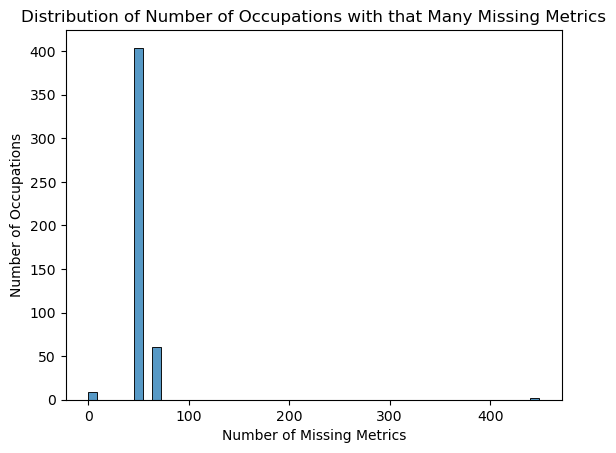

In [133]:
missing_values_hist_plot(df = df_pivoted, bins = 50, axis = 0)

It seems we have a group of occupations, as represented by the right most bar, that are missing a large proportion of their metrics. Elect to remove these occupations as they provide little data by which to analyze them and alternatively removing the missing metrics would greatly reduce our feature space:

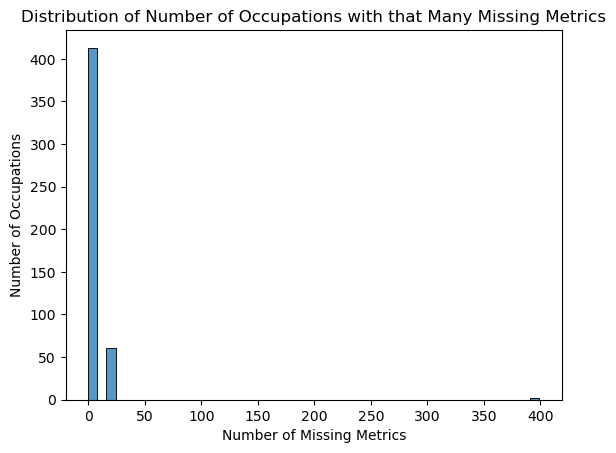

In [145]:
df_cleaned1 = drop_missing_values(df = df_pivoted, axis = 0, min_missing_values = 200)

# replot dist
missing_values_hist_plot(df = df_cleaned1, bins = 50, axis = 0)

Great now lets switch and look which variables are responsible for these missing values:

### Isolate Problematic Metrics

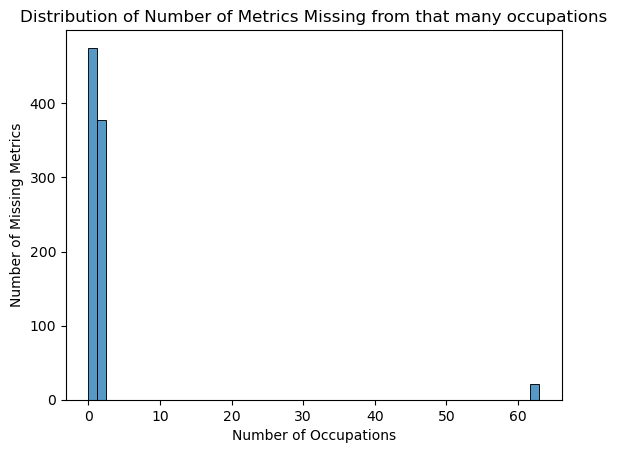

In [140]:
missing_values_hist_plot(df_cleaned1, bins = 50, axis = 1)

We can see a very large number of metrics that seem to be only missing from a small number of occupations as represented by the left most bar. These are good candidates for the removal of these problematic occupations.

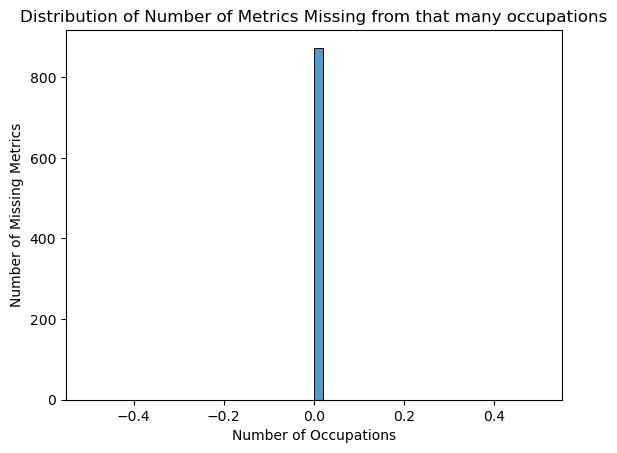

In [149]:
df_cleaned2 = drop_missing_values(df = df_cleaned1, axis = 1, min_missing_values = 50)
# replot dist
missing_values_hist_plot(df_cleaned2, bins = 50, axis = 1)

In [152]:
df_cleaned2.isna().sum().sum()

0

In [157]:
df_cleaned2.shape

(873, 413)

## Modeling

### Scaling

First lets scale our numeric data. Choose robust scaler to reduce the effect that outliers may have on our PCA vectors:

In [ ]:
# scale
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df_cleaned2)

### Dimensionality Reduction

Next apply PCA to condense our dataframe down to to variables (to become our x and y axes for our plot):

In [163]:
# dimensionality reduction
pca = PCA(n_components = 2)
reduced_data = pca.fit_transform(scaled_data)

# convert back to dataframe
pca_df = pd.DataFrame(data = reduced_data, columns = ['PCA_1', 'PCA_2'])
pca_df.head()

C:\Users\Jason\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\Jason\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(


,PCA_1,PCA_2
0,-17.709303,-5.528463
1,-13.527805,-1.049472
2,-8.510855,-0.478561
3,-10.109723,3.479354
4,-11.507067,1.244146


Now we need to merge back in our code data as well as occupation titles and description from the 'Occupation Data' Dataset:

In [166]:
occupation_data = pd.read_excel('db_28_2_excel/Occupation Data.xlsx')
# set code as index to match pca_df to make merging easier
occupation_data.set_index('O*NET-SOC Code', inplace = True)
occupation_data.head()

,Title,Description
O*NET-SOC Code,,
11-1011.00,Chief Executives,Determine and formulate policies and provide o...
11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."
11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ..."
11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes..."
11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici..."


In [169]:
# Re-establish code indexesin our pca dataframe
pca_df.index = df_cleaned2.index

# join df's based on codes
pca_df2 = pca_df.join(occupation_data)
pca_df2.head()

,PCA_1,PCA_2,Title,Description
O*NET-SOC Code,,,,
11-1011.00,-17.709303,-5.528463,Chief Executives,Determine and formulate policies and provide o...
11-1011.03,-13.527805,-1.049472,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."
11-1021.00,-8.510855,-0.478561,General and Operations Managers,"Plan, direct, or coordinate the operations of ..."
11-2011.00,-10.109723,3.479354,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici..."
11-2021.00,-11.507067,1.244146,Marketing Managers,"Plan, direct, or coordinate marketing policies..."


### Similarity Analysis

The user will select some key skills. interests etc and be used to find a starting point for their exploration. The best matched occupation based on the inputs will become the initial center of the plot.

Plan:
1. Represent the user's inputs as a binary vector where each element corresponds to a metric or feature in the dataset. Set the value to 1 for selected skills, interests etc, and 0 for non-selected attributes.

2. Calculate the similarity between the user's input vector and each row in the dataset using cosine similarity. Note although our Robust Scaler is not bounded, cosine similarity is concerned with direction only so a binary user vector is ok.

3. Return the top-ranked row as the best match

In [179]:
user_input = np.zeros(df_cleaned2.shape[1])
user_input[range(1, df_cleaned2.shape[1], 50)] = 1
np.where(user_input == 1)

(array([  1,  51, 101, 151, 201, 251, 301, 351, 401], dtype=int64),)

In [189]:
# reshape use_input to be 2d to match our df
user_input_reshaped = user_input.reshape(1, -1)
user_input_reshaped.shape

(1, 413)

In [188]:
similarities = cosine_similarity(user_input_reshaped, df_cleaned2)
similarities.shape

(1, 873)

In [190]:
# return index of best match
best_match_id = np.argmax(similarities)
best_match_id

386

In [205]:
# use pca_df to return occupation (use iloc as our indexes are the job codes)
print(f'Title: {pca_df2.iloc[1, 2]} \n Description: {pca_df2.iloc[1, 3]}')

Title: Chief Sustainability Officers 
 Description: Communicate and coordinate with management, shareholders, customers, and employees to address sustainability issues. Enact or oversee a corporate sustainability strategy.
